In [285]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import seaborn as sns
sns.set_style("whitegrid")
import pandas as pd
from adjustText import adjust_text
import sys

In [286]:
pwd

'/work/FAC/FGSE/IDYST/tbeucler/downscaling/sasthana/Downscaling/Processing_and_Analysis_Scripts/Analysis/Paper_Stats'

Masks : necessary for metrics 

In [287]:
Swiss_mask_LR = xr.open_dataset("../../../Downscaling_Models/Dataset_Setup_I_Chronological_12km/Swiss_LR_mask.nc")["TabsD"]
Swiss_mask_HR = xr.open_dataset("../../../Downscaling_Models/Dataset_Setup_I_Chronological_12km/Swiss_HR_mask.nc")["TabsD"]

In [288]:
print(Swiss_mask_LR.coords)
print(Swiss_mask_LR.shape)
print(Swiss_mask_LR.dims)

Coordinates:
    lon      (N, E) float32 2kB ...
    lat      (N, E) float32 2kB ...
  * E        (E) float64 240B 2.48e+06 2.492e+06 ... 2.816e+06 2.828e+06
  * N        (N) float64 160B 1.07e+06 1.082e+06 ... 1.286e+06 1.298e+06
(20, 30)
('N', 'E')


In [289]:
print(Swiss_mask_HR.coords)
print(Swiss_mask_HR.shape)
print(Swiss_mask_HR.dims)

Coordinates:
    lon      (N, E) float32 355kB ...
    lat      (N, E) float32 355kB ...
  * E        (E) float64 3kB 2.474e+06 2.476e+06 ... 2.842e+06 2.844e+06
  * N        (N) float64 2kB 1.064e+06 1.066e+06 ... 1.302e+06 1.304e+06
(240, 370)
('N', 'E')


The same mask applied to all analysis files $

SR deterministic baselines

In [290]:
pr_val = xr.open_dataset("../../data_1971_2023/HR_files_full/RhiresD_1971_2023.nc")["RhiresD"].sel(time=slice("2005-01-01", "2014-12-31"))
temp_val = xr.open_dataset("../../data_1971_2023/HR_files_full/TabsD_1971_2023.nc")["TabsD"].sel(time=slice("2005-01-01", "2014-12-31"))

In [291]:
pr_val = pr_val.where(Swiss_mask_HR, drop=False)

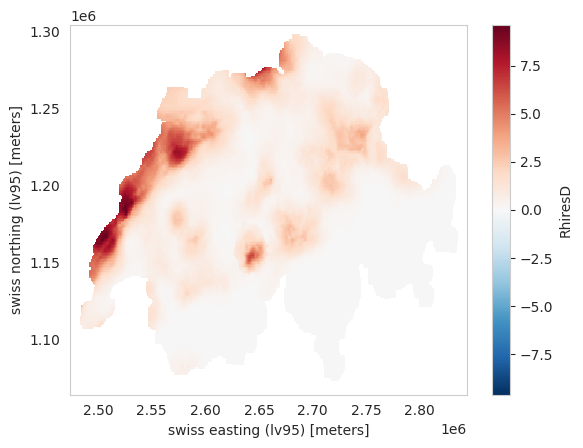

In [292]:
pr_val.sel(time=slice("2005-01-01", "2005-01-01")).mean(dim="time").plot()

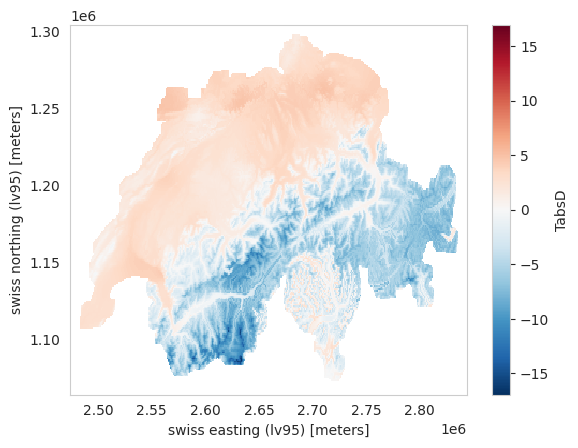

In [293]:
temp_val.sel(time=slice("2005-01-01", "2005-01-01")).mean(dim="time").plot()

Coarse baseline (val set evaluation)

In [294]:
coarse_pr_val= xr.open_dataset("../../../Downscaling_Models/Dataset_Setup_I_Chronological_12km/RhiresD_step2_coarse.nc")["RhiresD"].sel(time=slice("2005-01-01", "2014-12-31"))
coarse_temp_val= xr.open_dataset("../../../Downscaling_Models/Dataset_Setup_I_Chronological_12km/TabsD_step2_coarse.nc")["TabsD"].sel(time=slice("2005-01-01", "2014-12-31"))

In [295]:
coarse_pr_val = coarse_pr_val.where(Swiss_mask_LR,drop=True)
coarse_temp_val = coarse_temp_val.where(Swiss_mask_LR,drop=True)

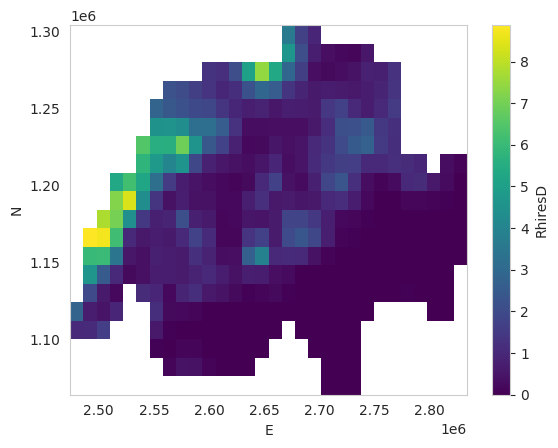

In [296]:
coarse_pr_val.sel(time=slice("2005-01-01", "2005-01-01")).mean(dim="time").plot()

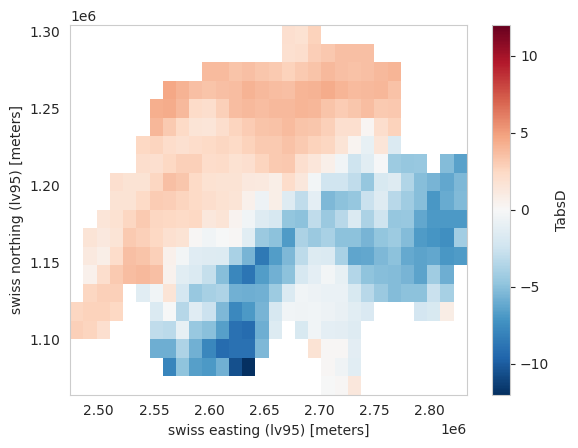

In [297]:
coarse_temp_val.sel(time=slice("2005-01-01", "2005-01-01")).mean(dim="time").plot()

Bicubic baselines

In [298]:
bicubic_pr_val= xr.open_dataset("../../../Downscaling_Models/Dataset_Setup_I_Chronological_12km/RhiresD_step3_interp_bicubic.nc")["RhiresD"].sel(time=slice("2005-01-01", "2014-12-31"))
bicubic_temp_val= xr.open_dataset("../../../Downscaling_Models/Dataset_Setup_I_Chronological_12km/TabsD_step3_interp_bicubic.nc")["TabsD"].sel(time=slice("2005-01-01", "2014-12-31"))

In [299]:
bicubic_pr_val = bicubic_pr_val.where(Swiss_mask_HR)
bicubic_temp_val = bicubic_temp_val.where(Swiss_mask_HR)

In [300]:
bicubic_pr_val.shape

(3652, 240, 370)

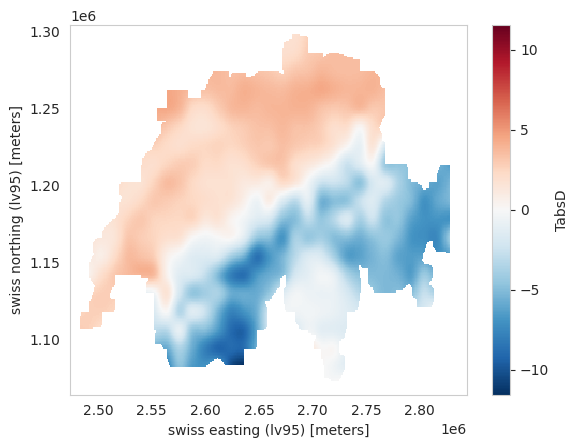

In [301]:
bicubic_temp_val.sel(time=slice("2005-01-01", "2005-01-01")).mean(dim="time").plot()

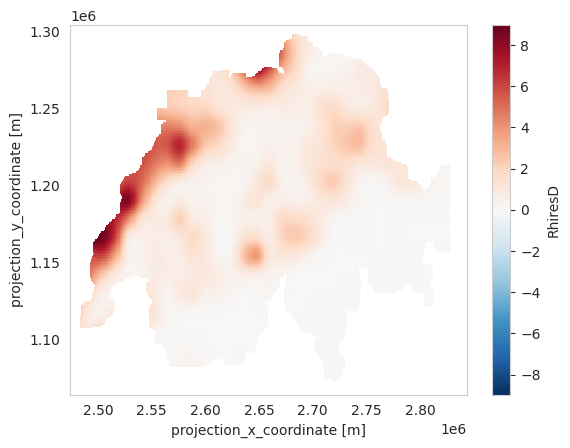

In [302]:
bicubic_pr_val.sel(time=slice("2005-01-01", "2005-01-01")).mean(dim="time").plot()

Bilinear baselines

In [303]:
bilinear_pr_val= xr.open_dataset("../../../Downscaling_Models/Dataset_Setup_I_Chronological_12km/RhiresD_step3_interp_bilinear.nc")["RhiresD"].sel(time=slice("2005-01-01", "2014-12-31"))
bilinear_temp_val= xr.open_dataset("../../../Downscaling_Models/Dataset_Setup_I_Chronological_12km/TabsD_step3_interp_bilinear.nc")["TabsD"].sel(time=slice("2005-01-01", "2014-12-31"))

In [304]:
bilinear_pr_val= bilinear_pr_val.where(Swiss_mask_HR)
bilinear_temp_val= bilinear_temp_val.where(Swiss_mask_HR)

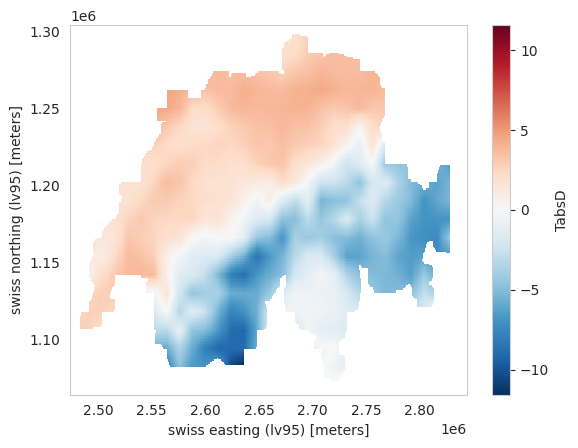

In [305]:
bilinear_temp_val.sel(time=slice("2005-01-01", "2005-01-01")).mean(dim="time").plot()

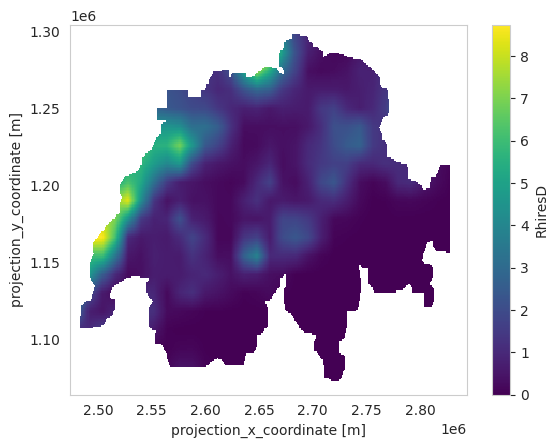

In [306]:
bilinear_pr_val.sel(time=slice("2005-01-01", "2005-01-01")).mean(dim="time").plot()

UNet baselines : bilinear and bicubic

In [307]:
bilinear_unet_precip=xr.open_dataset("../../../Downscaling_Models/DDIM_conditional_derived/output_inference/BILINEAR_unet_downscaled_val_set.nc")["precip"].sel(time=slice("2005-01-01", "2014-12-31"))
bilinear_unet_temp=xr.open_dataset("../../../Downscaling_Models/DDIM_conditional_derived/output_inference/BILINEAR_unet_downscaled_val_set.nc")["temp"].sel(time=slice("2005-01-01", "2014-12-31"))

In [308]:
bicubic_unet_precip=xr.open_dataset("../../../Downscaling_Models/DDIM_conditional_derived/output_inference/BICUBIC_unet_downscaled_val_set.nc")["precip"].sel(time=slice("2005-01-01", "2014-12-31"))
bicubic_unet_temp=xr.open_dataset("../../../Downscaling_Models/DDIM_conditional_derived/output_inference/BICUBIC_unet_downscaled_val_set.nc")["temp"].sel(time=slice("2005-01-01", "2014-12-31"))

In [309]:
bilinear_unet_precip = bilinear_unet_precip.where(Swiss_mask_HR)
bicubic_unet_precip = bicubic_unet_precip.where(Swiss_mask_HR)
bilinear_unet_temp = bilinear_unet_temp.where(Swiss_mask_HR)
bicubic_unet_temp = bicubic_unet_temp.where(Swiss_mask_HR)

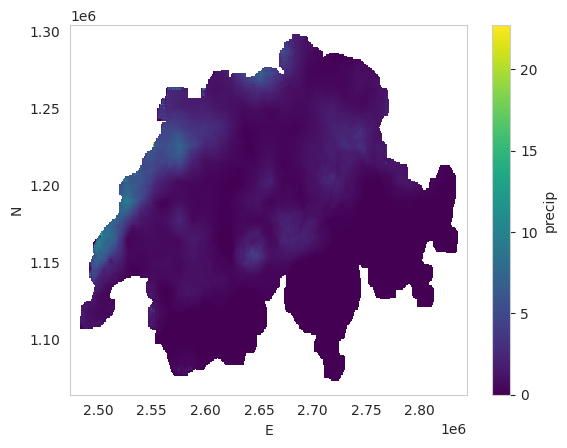

In [310]:
bilinear_unet_precip.sel(time=slice("2005-01-01", "2005-01-01")).mean(dim="time").plot()

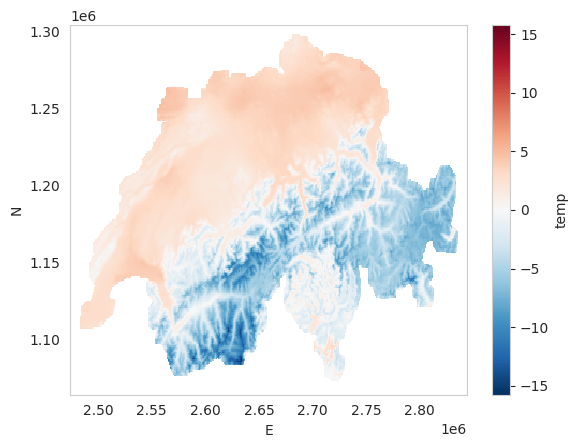

In [311]:
bilinear_unet_temp.sel(time=slice("2005-01-01", "2005-01-01")).mean(dim="time").plot()


Deterministic UNet baseline

Metrics : RMSE, and SSIM

In [312]:
#Spatial mean time series of files 
pr_val_spatial_mean = pr_val.mean(dim=["N", "E"])
temp_val_spatial_mean = temp_val.mean(dim=["N", "E"])

In [313]:
coarse_pr_spatial_mean = coarse_pr_val.mean(dim=["N", "E"])
coarse_temp_spatial_mean = coarse_temp_val.mean(dim=["N", "E"])

Interpolation baselines

In [314]:
bilinear_pr_val_spatial_mean = bilinear_pr_val.mean(dim=["N", "E"])
bilinear_temp_val_spatial_mean = bilinear_temp_val.mean(dim=["N", "E"])
bicubic_pr_val_spatial_mean = bicubic_pr_val.mean(dim=["N", "E"])
bicubic_temp_val_spatial_mean = bicubic_temp_val.mean(dim=["N", "E"])

unet!

In [315]:
bilinear_unet_precip_spatial_mean = bilinear_unet_precip.mean(dim=["N", "E"])
bilinear_unet_temp_spatial_mean = bilinear_unet_temp.mean(dim=["N", "E"])
bicubic_unet_precip_spatial_mean = bicubic_unet_precip.mean(dim=["N", "E"])
bicubic_unet_temp_spatial_mean = bicubic_unet_temp.mean(dim=["N", "E"])

In [316]:
def rmse(predictions, targets):
    return float(np.sqrt(((predictions - targets) ** 2).mean()))

In [317]:
pr_coarse_rmse = rmse(coarse_pr_spatial_mean , pr_val_spatial_mean)
temp_coarse_rmse = rmse(coarse_temp_spatial_mean , temp_val_spatial_mean)
pr_bilinear_rmse = rmse(bilinear_pr_val_spatial_mean , pr_val_spatial_mean)
temp_bilinear_rmse = rmse(bilinear_temp_val_spatial_mean , temp_val_spatial_mean)
pr_bicubic_rmse = rmse(bicubic_pr_val_spatial_mean, pr_val_spatial_mean)
temp_bicubic_rmse = rmse(bicubic_temp_val_spatial_mean, temp_val_spatial_mean)
unet_bilinear_pr_rmse = rmse(bilinear_unet_precip_spatial_mean, pr_val_spatial_mean)
unet_bilinear_temp_rmse = rmse(bilinear_unet_temp_spatial_mean, temp_val_spatial_mean)
unet_bicubic_pr_rmse = rmse(bicubic_unet_precip_spatial_mean, pr_val_spatial_mean)
unet_bicubic_temp_rmse = rmse(bicubic_unet_temp_spatial_mean, temp_val_spatial_mean)

RMSE table 

In [318]:
results = pd.DataFrame({
    'Val Set': ['Coarse', 'Bic', 'Bil', 'UNetBil', 'UNetBic'],
    'Pr RMSE': [pr_coarse_rmse, pr_bicubic_rmse, pr_bilinear_rmse, unet_bilinear_pr_rmse, unet_bicubic_pr_rmse],
    'Temp RMSE': [temp_coarse_rmse, temp_bicubic_rmse, temp_bilinear_rmse, unet_bilinear_temp_rmse, unet_bicubic_temp_rmse],
})

In [319]:
print(results)

   Val Set        Pr RMSE  Temp RMSE
0   Coarse       0.355073   0.093820
1      Bic       0.039108   0.031951
2      Bil       0.041369   0.027628
3  UNetBil       0.190572   0.025704
4  UNetBic  142656.906250   0.015861


In [320]:
import sys

In [321]:
from ssim_precip import framewise_ssim as ssim_precip
from ssim_temp import framewise_ssim as ssim_temp

Mean SSIM across all timesteps for val .. set. 

In [322]:
pr_bicubic_ssim = ssim_precip(pr_val, bicubic_pr_val)
pr_bilinear_ssim = ssim_precip(pr_val, bilinear_pr_val)
pr_unet_bilinear_ssim = ssim_precip(pr_val, bilinear_unet_precip)
pr_unet_bicubic_ssim = ssim_precip(pr_val, bicubic_unet_precip)

/work/FAC/FGSE/IDYST/tbeucler/downscaling/sasthana/Downscaling/Downscaling_Models/.micromamba/envs/diffscaler/lib/python3.9/site-packages/skimage/metrics/_structural_similarity.py:230: RuntimeWarning: invalid value encountered in divide
  S = (A1 * A2) / D
/work/FAC/FGSE/IDYST/tbeucler/downscaling/sasthana/Downscaling/Downscaling_Models/.micromamba/envs/diffscaler/lib/python3.9/site-packages/skimage/metrics/_structural_similarity.py:229: RuntimeWarning: overflow encountered in multiply
  D = B1 * B2


In [323]:
print(temp_val.shape)        # should be (3652, 240, 370)
print(bicubic_temp_val.shape) # should be (3652, 240, 370)

(3652, 240, 370)
(3652, 240, 370)


In [324]:
temp_bicubic_ssim = ssim_temp(temp_val, bicubic_temp_val)
temp_bilinear_ssim = ssim_temp(temp_val, bilinear_temp_val)
temp_unet_bilinear_ssim = ssim_temp(temp_val, bilinear_unet_temp)
temp_unet_bicubic_ssim = ssim_temp(temp_val, bicubic_unet_temp)

In [325]:
results = pd.DataFrame({
    'Val Set': ['Bic', 'Bil', 'UNetBil', 'UNetBic'],
    'Precipitation SSIM': [pr_bicubic_ssim, pr_bilinear_ssim, pr_unet_bilinear_ssim, pr_unet_bicubic_ssim],
    'Temperature SSIM': [temp_bicubic_ssim, temp_bilinear_ssim, temp_unet_bilinear_ssim, temp_unet_bicubic_ssim]
})

print(results)

   Val Set  Precipitation SSIM  Temperature SSIM
0      Bic            0.948523          0.733078
1      Bil            0.936342          0.725566
2  UNetBil            0.941897          0.974610
3  UNetBic            0.937846          0.970192


In [326]:
print("UNetBic precip min/max:", float(bicubic_unet_precip.min()), float(bicubic_unet_precip.max()))
print("UNetBil precip min/max:", float(bilinear_unet_precip.min()), float(bilinear_unet_precip.max()))
print("pr_val min/max:        ", float(pr_val.min()),               float(pr_val.max()))

UNetBic precip min/max: 9.41672568026277e-43 361376382976.0
UNetBil precip min/max: 9.41672568026277e-43 22292.482421875
pr_val min/max:         -1.1064081074929621e-11 284.1131286621094
